### Predictive Analytics:

In [9]:
pip install tensorflow

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
xl = pd.ExcelFile('Analytics_Dataset.xlsx')
print(xl.sheet_names)

['Stock_Prices', 'Sales_Data', 'Waiter_Tips']


(1000, 7)


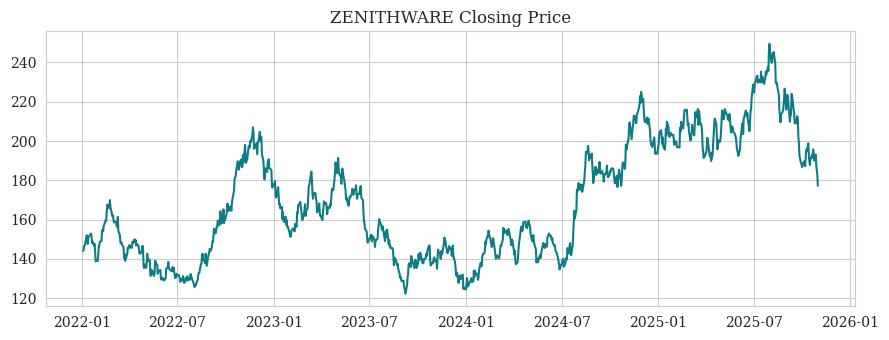

In [4]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
tf.random.set_seed(42)
stock = pd.read_excel('Analytics_Dataset.xlsx', sheet_name='Stock_Prices', parse_dates=['date'])
zenithware = stock[stock['ticker']=='ZENITHWARE'].sort_values('date').reset_index(drop=True)
print(zenithware.shape)
plt.figure(figsize=(9,3.5))
plt.plot(zenithware['date'], zenithware['close'], color='#0E7C86')
plt.title('ZENITHWARE Closing Price')
plt.tight_layout(); plt.show()

In [5]:
prices = zenithware['close'].values.reshape(-1,1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)
WINDOW = 20
X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)   # [samples, timesteps, features]
# Time-based split: train on the earlier ~80%, test on the later ~20% (never shuffle time series)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (784, 20, 1)  Test: (196, 20, 1)


In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.LSTM(32, return_sequences=False),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1),
])
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

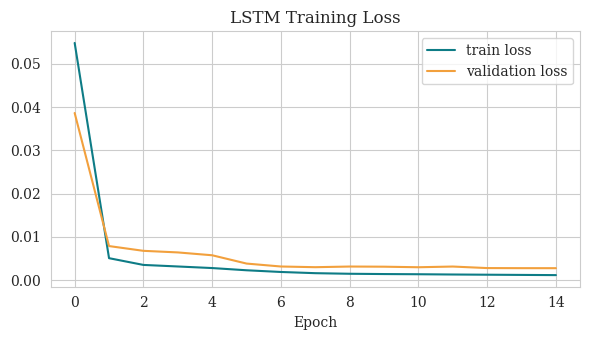

In [7]:
history = model.fit(X_train, y_train, epochs=15, batch_size=16,
                     validation_data=(X_test, y_test), verbose=0)
plt.figure(figsize=(6,3.5))
plt.plot(history.history['loss'], label='train loss', color='#0E7C86')
plt.plot(history.history['val_loss'], label='validation loss', color='#F2A03D')
plt.legend(); plt.title('LSTM Training Loss'); plt.xlabel('Epoch')
plt.tight_layout(); plt.show()

LSTM RMSE on held-out (later) test dates: $6.67


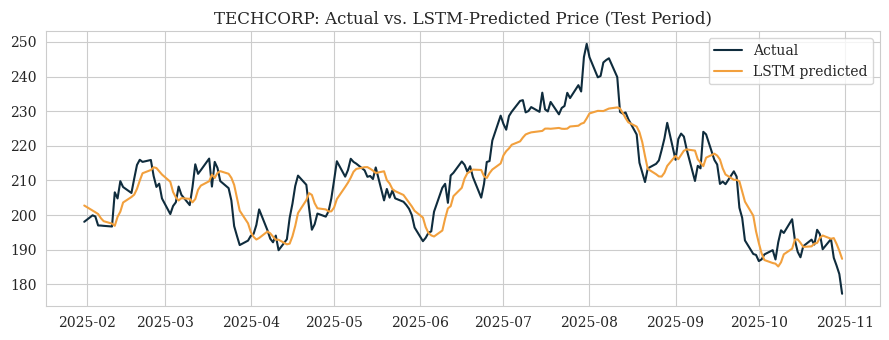

In [8]:
pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1,1))
rmse = mean_squared_error(actual, pred) ** 0.5
print(f"LSTM RMSE on held-out (later) test dates: ${rmse:.2f}")
test_dates = techcorp['date'].values[WINDOW+split:]
plt.figure(figsize=(9,3.5))
plt.plot(test_dates, actual, label='Actual', color='#0F2C3D')
plt.plot(test_dates, pred, label='LSTM predicted', color='#F2A03D')
plt.title('TECHCORP: Actual vs. LSTM-Predicted Price (Test Period)')
plt.legend(); plt.tight_layout(); plt.show()

### Sales Forecasting and Time-Series Analysis

(1000,)


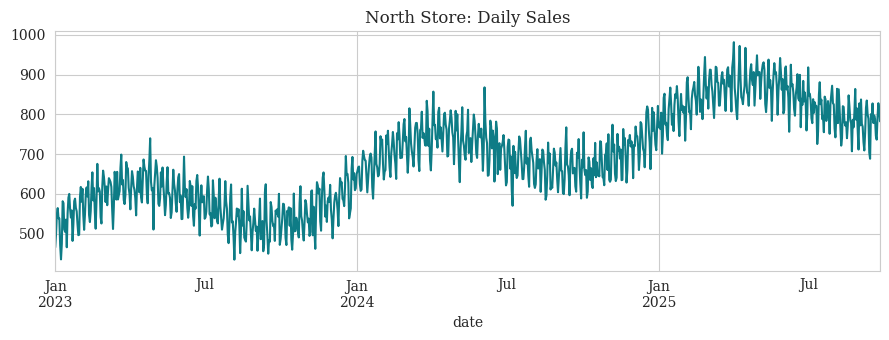

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
sales = pd.read_excel('Analytics_Dataset.xlsx', sheet_name='Sales_Data', parse_dates=['date'])
north = sales[sales['store']=='North'].sort_values('date').set_index('date')['sales']
print(north.shape)
north.plot(figsize=(9,3.5), color='#0E7C86', title='North Store: Daily Sales')
plt.tight_layout(); plt.show()

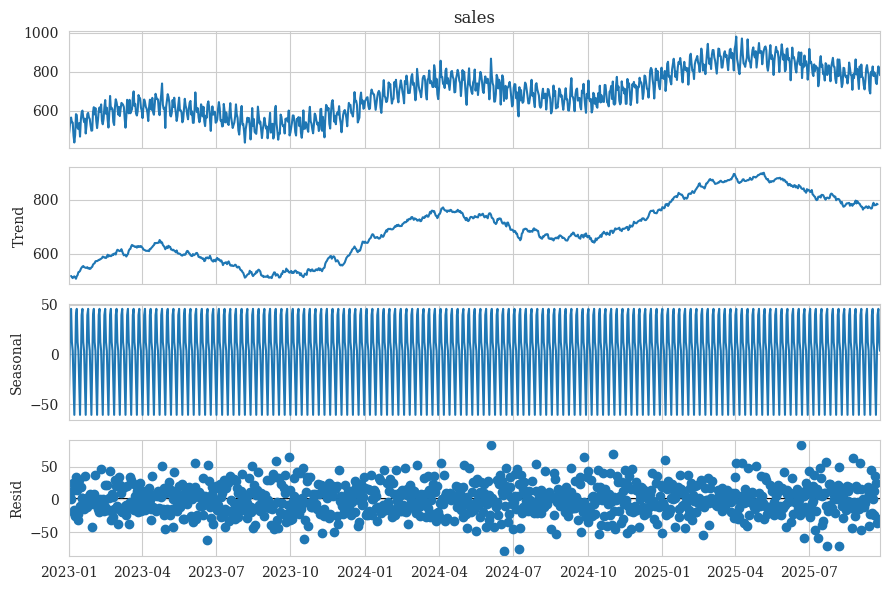

In [11]:
decomp = seasonal_decompose(north, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(9,6)
plt.tight_layout(); plt.show()

C:\Users\ShellBD\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Holt-Winters RMSE on held-out 60 days: 28.2 units/day


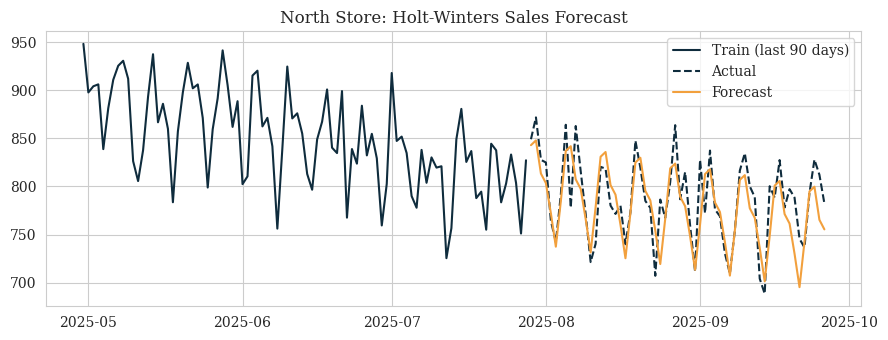

In [12]:
train, test = north[:-60], north[-60:]
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast = hw_model.forecast(len(test))
rmse_hw = mean_squared_error(test, forecast) ** 0.5
print(f"Holt-Winters RMSE on held-out 60 days: {rmse_hw:.1f} units/day")
plt.figure(figsize=(9,3.5))
plt.plot(train[-90:], label='Train (last 90 days)', color='#0F2C3D')
plt.plot(test, label='Actual', color='#0F2C3D', linestyle='--')
plt.plot(test.index, forecast, label='Forecast', color='#F2A03D')
plt.title('North Store: Holt-Winters Sales Forecast')
plt.legend(); plt.tight_layout(); plt.show()

### Waiter Tips Prediction and Regression

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
tips = pd.read_excel('Analytics_Dataset.xlsx', sheet_name='Waiter_Tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,11.65,2.31,Male,No,Fri,Lunch,1
1,39.07,5.90,Male,No,Sun,Lunch,6
2,31.99,3.44,Male,No,Sat,Lunch,5
3,30.29,4.17,Male,Yes,Sat,Dinner,2
4,22.84,3.08,Male,No,Sat,Dinner,2


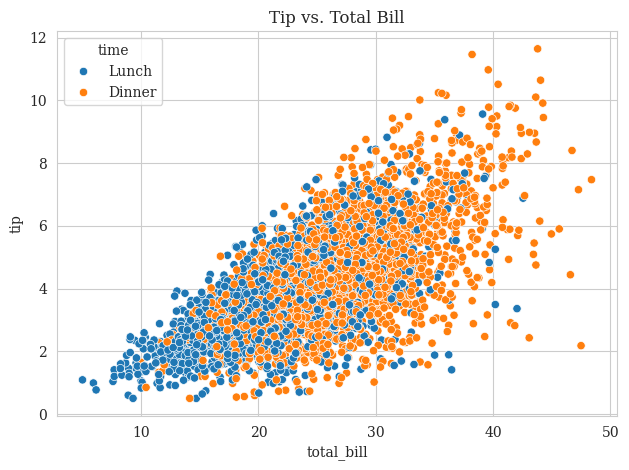

Correlation between total_bill and tip: 0.665


In [15]:
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time')
plt.title('Tip vs. Total Bill')
plt.tight_layout(); plt.show()
print("Correlation between total_bill and tip:", round(tips['total_bill'].corr(tips['tip']), 3))

In [16]:
X = tips.drop(columns='tip')
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_cols = ['sex','smoker','day','time']
num_cols = ['total_bill','size']
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols),
])
baseline = LinearRegression()
baseline.fit(X_train[['total_bill']], y_train)
baseline_pred = baseline.predict(X_test[['total_bill']])
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"Baseline (total_bill only) R²: {baseline_r2:.3f}")

Baseline (total_bill only) R²: 0.472


In [17]:
linreg_pipe = Pipeline([('prep', preprocess), ('model', LinearRegression())])
linreg_pipe.fit(X_train, y_train)
linreg_pred = linreg_pipe.predict(X_test)
linreg_r2 = r2_score(y_test, linreg_pred)
print(f"Refined linear regression (all features) R²: {linreg_r2:.3f}")
ridge_pipe = Pipeline([('prep', preprocess), ('model', Ridge(alpha=1.0))])
ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)
print(f"Ridge regression (all features) R²: {ridge_r2:.3f}")
rf_pipe = Pipeline([('prep', preprocess), ('model', RandomForestRegressor(n_estimators=200, random_state=42))])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest (all features) R²: {rf_r2:.3f}")

Refined linear regression (all features) R²: 0.514
Ridge regression (all features) R²: 0.514
Random Forest (all features) R²: 0.410


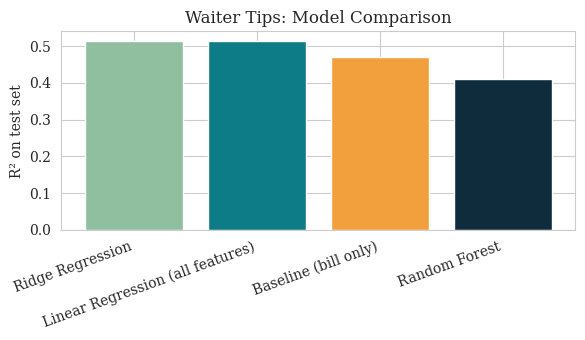

,Model,R2
0,Ridge Regression,0.514342
1,Linear Regression (all features),0.514309
2,Baseline (bill only),0.471554
3,Random Forest,0.409878


In [18]:
comparison = pd.DataFrame({
    "Model": ["Baseline (bill only)", "Linear Regression (all features)", "Ridge Regression", "Random Forest"],
    "R2": [baseline_r2, linreg_r2, ridge_r2, rf_r2],
})
comparison = comparison.sort_values("R2", ascending=False).reset_index(drop=True)
plt.figure(figsize=(6,3.5))
plt.bar(comparison['Model'], comparison['R2'], color=['#8FBF9F','#0E7C86','#F2A03D','#0F2C3D'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('R² on test set')
plt.title('Waiter Tips: Model Comparison')
plt.tight_layout(); plt.show()
comparison

### Deploying a Prediction Pipeline

In [19]:
import joblib
joblib.dump(rf_pipe, 'tips_pipeline.joblib')
print("Pipeline saved to tips_pipeline.joblib")
loaded_pipe = joblib.load('tips_pipeline.joblib')
new_bills = pd.DataFrame([
    {"total_bill": 45.00, "sex": "Male", "smoker": "No", "day": "Sat", "time": "Dinner", "size": 4},
    {"total_bill": 18.50, "sex": "Female", "smoker": "Yes", "day": "Thur", "time": "Lunch", "size": 2},
])
predicted_tips = loaded_pipe.predict(new_bills)
new_bills['predicted_tip'] = predicted_tips.round(2)
new_bills

Pipeline saved to tips_pipeline.joblib


,total_bill,sex,smoker,day,time,size,predicted_tip
0,45.0,Male,No,Sat,Dinner,4,7.74
1,18.5,Female,Yes,Thur,Lunch,2,2.64
